---
# NLI Evaluation
> Laura Komorek
---

This notebook evaluates our fine-tuned RoBERTa Models on the testsets of our datasets:
- OntoNOTES (RoBERTa-Base)
- FIGER (distilled-RoBERTa)
- UltraFine (distilled-RoBERTa)

Here we compute:
- Precision, Recall, F1 (micro and macro)
- a Micro vs. Macro comparision
- a Per-Label (type) analysis
- a Frequency vs. Performance comparision
- Visualizations

---
## Imports and Config

In [1]:
import json
import os
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# -- Config

datasets = {
    "ontonotes": "ontonotes_test_predictions.json",
    "figer": "figer_test_predictions.json",
    "ultrafine": "ultra_test_predictions.json",
}

output_dir = "evaluation_results"
os.makedirs(output_dir, exist_ok=True)


---
## Helper Functions

In [2]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    y_true = [item["gold_label"] for item in data]
    y_pred = [item["prediction"] for item in data]
    
    return y_true, y_pred, data


def compute_metrics(y_true, y_pred):
    return {
        "precision_micro": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "recall_micro": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def per_label_analysis(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    freq = Counter(y_true)
    
    rows = []
    for label in freq:
        if label in report:
            rows.append({
                "label": label,
                "frequency": freq[label],
                "precision": report[label]["precision"],
                "recall": report[label]["recall"],
                "f1": report[label]["f1-score"],
            })
    
    return pd.DataFrame(rows)

---
## Type Extraction

In [3]:
def extract_type(example):
    hypo = example["hypothesis"]
    if " is a " in hypo:
        return hypo.split(" is a ")[-1].replace(".", "").strip()
    return "unknown"


def per_type_analysis(data, y_true, y_pred):
    types = [extract_type(x) for x in data]
    
    df = pd.DataFrame({
        "type": types,
        "y_true": y_true,
        "y_pred": y_pred
    })
    
    results = []
    
    for t in df["type"].unique():
        subset = df[df["type"] == t]
        
        if len(subset) < 5:
            continue
        
        f1 = f1_score(subset["y_true"], subset["y_pred"], average="macro")
        
        results.append({
            "type": t,
            "frequency": len(subset),
            "f1": f1
        })
    
    return pd.DataFrame(results)

---
## Evaluation


Evaluating ontonotes
{'precision_micro': 0.75, 'recall_micro': 0.75, 'f1_micro': 0.75, 'precision_macro': 0.375, 'recall_macro': 0.5, 'f1_macro': 0.42857142857142855, 'dataset': 'ontonotes'}


,label,frequency,precision,recall,f1
0,NOT ENTAILMENT,16944,0.75,1.0,0.857143
1,ENTAILMENT,5648,0.00,0.0,0.000000


,type,frequency,f1
0,per,5648,0.416469
1,loc,5648,0.413378
2,org,5648,0.413804
3,misc,5648,0.466868


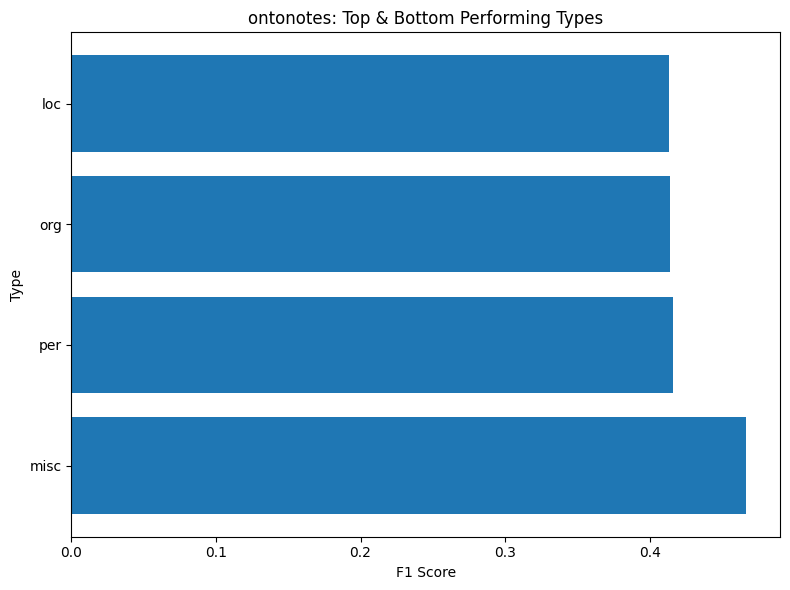


Evaluating figer
{'precision_micro': 0.69176, 'recall_micro': 0.69176, 'f1_micro': 0.69176, 'precision_macro': 0.34588, 'recall_macro': 0.5, 'f1_macro': 0.4088996075093394, 'dataset': 'figer'}


,label,frequency,precision,recall,f1
0,ENTAILMENT,138352,0.69176,1.0,0.817799
1,NOT ENTAILMENT,61648,0.00000,0.0,0.000000


,type,frequency,f1
0,/common/topic,12446,1.000000
1,/people/deceased_person,1004,0.498752
2,/user/stevec/default_domain/drink,21,0.192308
3,/base/ttiff/topic,8,0.000000
4,/m/0bb0p64,7,0.000000


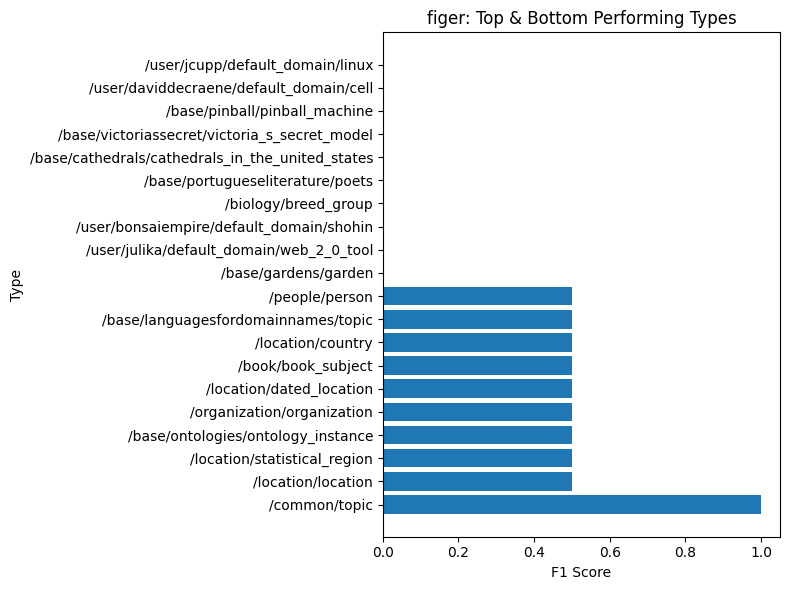


Evaluating ultrafine
{'precision_micro': 0.996806259291396, 'recall_micro': 0.996806259291396, 'f1_micro': 0.996806259291396, 'precision_macro': 0.498403129645698, 'recall_macro': 0.5, 'f1_macro': 0.4992002877861227, 'dataset': 'ultrafine'}


,label,frequency,precision,recall,f1
0,NOT ENTAILMENT,3349903,0.996806,1.0,0.998401
1,ENTAILMENT,10733,0.000000,0.0,0.000000


,type,frequency,f1
0,size,1998,0.499875
1,scientist,1998,0.498494
2,capitalist,1998,0.499374
3,commodity,1998,0.499248
4,panic,1998,0.499875


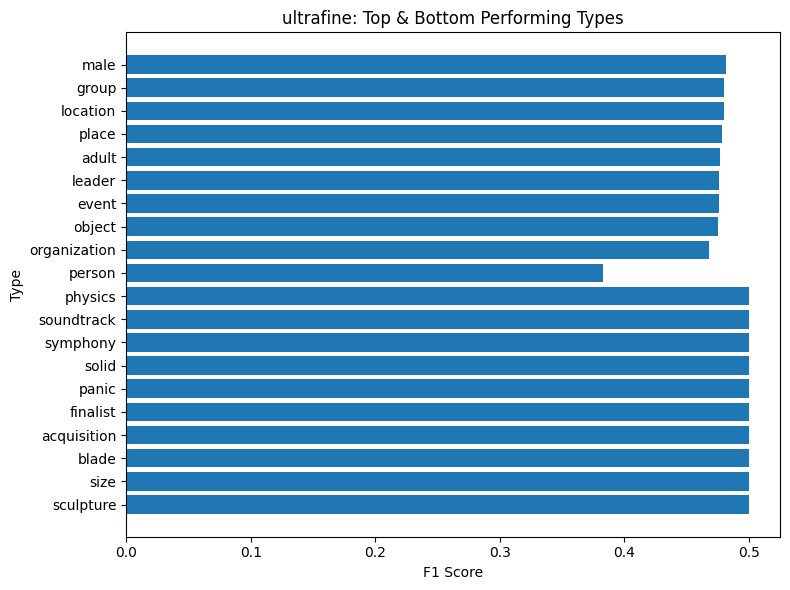

In [10]:
all_results = []

for dataset_name, path in datasets.items():
    print(f"\nEvaluating {dataset_name}")
    
    y_true, y_pred, raw_data = load_json(path)
    
    # -- Overall Metrics
    metrics = compute_metrics(y_true, y_pred)
    metrics["dataset"] = dataset_name
    all_results.append(metrics)
    
    print(metrics)
    
    # --Per-label (ENTAILMENT vs NOT)
    df_labels = per_label_analysis(y_true, y_pred)
    display(df_labels)
    
    # -- Type-based analysis
    df_types = per_type_analysis(raw_data, y_true, y_pred)
    display(df_types.head())
    
    # -- Save
    df_labels.to_csv(f"{output_dir}/{dataset_name}_labels.csv", index=False)
    df_types.to_csv(f"{output_dir}/{dataset_name}_types.csv", index=False)
    
    df_labels.to_latex(f"{output_dir}/{dataset_name}_labels.tex", index=False)
    df_types.to_latex(f"{output_dir}/{dataset_name}_types.tex", index=False)
    
    # -- Plot: F1 Score 
    top_k = 10
    top_types = df_types.sort_values("f1", ascending=False).head(top_k)
    bottom_types = df_types.sort_values("f1").head(top_k)
    df_plot = pd.concat([top_types, bottom_types])

    plt.figure(figsize=(8,6))
    plt.barh(df_plot["type"], df_plot["f1"])
    plt.xlabel("F1 Score")
    plt.ylabel("Type")
    plt.title(f"{dataset_name}: Top & Bottom Performing Types")
    plt.tight_layout()
    plt.show()

---
## General Comparision

In [11]:
df_all = pd.DataFrame(all_results)
display(df_all)

df_all.to_csv(f"{output_dir}/overall_metrics.csv", index=False)
df_all.to_latex(f"{output_dir}/overall_metrics.tex", index=False)

,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,dataset
0,0.750000,0.750000,0.750000,0.375000,0.5,0.428571,ontonotes
1,0.691760,0.691760,0.691760,0.345880,0.5,0.408900,figer
2,0.996806,0.996806,0.996806,0.498403,0.5,0.499200,ultrafine


---
## Micro vs. Macro (Plot)

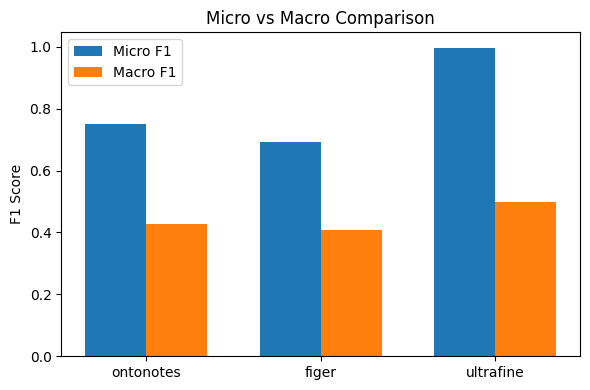

In [12]:
plt.figure(figsize=(6, 4))

x = np.arange(len(df_all))
width = 0.35

plt.bar(x - width/2, df_all["f1_micro"], width, label="Micro F1")
plt.bar(x + width/2, df_all["f1_macro"], width, label="Macro F1")

plt.xticks(x, df_all["dataset"])
plt.ylabel("F1 Score")
plt.title("Micro vs Macro Comparison")

plt.legend()
plt.tight_layout()
plt.show()

---
## Interpretation of Analysis

---
### Overall Performance
---
The results show a rather large gap between our micro and macro F1 scores across all of our datasets

For example:
- UltraFine achieves a micro F1 of ~0.99
- but only a macro F1 of ~0.50

That indicates that there is a strong class imbalance:
- The models performes well on the majority class ("NOT ENTAILMENT")
- but has struggles to correctly predict the minority class ("ENTAILMENT")

Therefore, as a result, micro F1 is overly optimistic while macro F1 provides a more realistic view of the models performance.

This imbalance between the two classes is most likely the result of the training and finetuning.

Our training data had more "NOT ENTAILMENT" predictions than "ENTAILMENT" predictions generally.

That was to be expected due to the fact that, for example: \
Our Premise:
- "Apple released a new iPhone." 

For this we say our only true Hypothesis is:
- "Apple is an organisation"

We have limited the amount of negative classifications during preprocessing, yet however there are still multiple negative classifications and only one positive classification. 

Because of this our model learned that "NOT ENTAILMENT" must be the majority class, resulting in often falsely classifications on our test sets.

---
### Type-Based Analysis
---
The task is formulated as textual entailment, where each mention is paired with multiple candidate types.

This however leads to an important consequence:
- Each types appears approximately the same number of times in the dataset
- Therefore, our type frequency does not vary significantly

As a results, a frequency vs. performance analysis is not very meaningful in our setup.

So instead we decided to analyze performance differences across the types directly.

---
### Performance Across Types
---
The analysis reveals that performance varies across types, despite the similar frequencies.

We can observe that:
- Some typse achieve consistently higher F1 scores
- Othet types are significantly harder to predict

That suggests that:
- The model captures certain semantic categories better than others
- Fine-grained distinctions between types however remain challenging

This behaviour highlights the limitations of the model in handling subtle sementic differences between the entitiy types.

---
### OntoNotes Analysis
---
For OntoNotes, our number of distinct types is relatively small.

As a result:
- Only a few data points are availabel for tpye-based analysis
- This limites the interpretability of type-level plots

In contrast however, FIGER and UltraFine provide a more fine-grained type space, making them way more suitable for this analysis

---
### Conclusion
---
Overall, the NLI evaluation shows that:
- The model performs well on the majority class, but struggles with the minority class
- Macro F1 reveals significant weaknesses that are hidden by the Micro F1
- Performance varies across entity types, even when frequencies are similar

All of these findings indicate that:
- Class imbalance is a major challenge
- Fine-grained entity typing does remain difficult for the model